# XKCD Style in Lets-Plot

XKCD-style charts mimic the hand-drawn look of webcomics.

The effect is achieved by adding a subtle "wobble" to lines and shape edges.

In [1]:
import pandas as pd
import numpy as np
from lets_plot import *

In [2]:
LetsPlot.setup_html(no_js=True)

## 1. Line Charts

The wobble effect is most visible on line charts (`geom_line`, `geom_path`).

In [3]:
# Simple line chart
x = np.linspace(0, 10, 50)
y = np.sin(x)

line_data = pd.DataFrame({'x': x, 'y': y})

(
    ggplot(line_data, aes('x', 'y')) +
    geom_line(size=2, color='#1976D2') +
    ggtitle('Sine Wave') +
    theme_classic()
)

In [4]:
# Multiple lines
x = np.linspace(0, 8, 40)
data = pd.DataFrame({
    'x': np.tile(x, 3),
    'y': np.concatenate([np.sin(x), np.cos(x), np.sin(x) * np.cos(x)]),
    'Function': np.repeat(['sin(x)', 'cos(x)', 'sin(x)*cos(x)'], len(x))
})

(
    ggplot(data, aes('x', 'y', color='Function')) +
    geom_line(size=2) +
    ggtitle('Trigonometric Functions') +
    theme_classic()
)

## 2. Bar Charts

Bars get wobbly edges, giving them a sketched appearance.

In [5]:
# Simple bar chart
bar_data = pd.DataFrame({
    'category': ['A', 'B', 'C', 'D', 'E'],
    'value': [23, 45, 32, 58, 41]
})

(
    ggplot(bar_data, aes('category', 'value')) +
    geom_bar(stat='identity', fill='#43A047', color='black', size=1) +
    ggtitle('Sales by Category') +
    theme_classic()
)

In [6]:
# Grouped bar chart
grouped_data = pd.DataFrame({
    'quarter': ['Q1', 'Q2', 'Q3', 'Q4'] * 2,
    'revenue': [120, 150, 180, 200, 100, 130, 160, 190],
    'year': ['2023'] * 4 + ['2024'] * 4
})

(
    ggplot(grouped_data, aes('quarter', 'revenue', fill='year')) +
    geom_bar(stat='identity', position='dodge', color='black', size=0.8) +
    scale_fill_manual(values=['#FF7043', '#42A5F5']) +
    ggtitle('Quarterly Revenue Comparison') +
    theme_classic()
)

## 3. Area Charts

Area fills also get the hand-drawn treatment.

In [7]:
# Area chart
x = np.linspace(0, 10, 50)
area_data = pd.DataFrame({
    'x': x,
    'y': np.abs(np.sin(x) * 5 + np.random.normal(0, 0.3, len(x)))
})

(
    ggplot(area_data, aes('x', 'y')) +
    geom_area(fill='#7E57C2', alpha=0.7) +
    geom_line(size=1.5, color='#4527A0') +
    ggtitle('Stock Price Movement') +
    theme_classic()
)

In [8]:
# Stacked area
np.random.seed(42)
months = np.arange(1, 13)
stacked_data = pd.DataFrame({
    'month': np.tile(months, 3),
    'visitors': np.concatenate([
        100 + np.cumsum(np.random.randint(-5, 15, 12)),
        80 + np.cumsum(np.random.randint(-5, 12, 12)),
        60 + np.cumsum(np.random.randint(-3, 10, 12))
    ]),
    'source': np.repeat(['Organic', 'Social', 'Direct'], 12)
})

(
    ggplot(stacked_data, aes('month', 'visitors', fill='source')) +
    geom_area(alpha=0.8, position='stack') +
    scale_fill_manual(values=['#66BB6A', '#42A5F5', '#FFA726']) +
    scale_x_continuous(breaks=list(range(1, 13))) +
    ggtitle('Website Traffic by Source') +
    theme_classic()
)

## 4. Segments and Error Bars

Even technical elements like error bars get the sketchy treatment.

In [9]:
# Error bars
error_data = pd.DataFrame({
    'treatment': ['Control', 'Drug A', 'Drug B', 'Drug C'],
    'mean': [10, 15, 22, 18],
    'se': [1.2, 1.8, 2.1, 1.5]
})
error_data['ymin'] = error_data['mean'] - error_data['se']
error_data['ymax'] = error_data['mean'] + error_data['se']

(
    ggplot(error_data, aes('treatment', 'mean')) +
    geom_bar(stat='identity', fill='#26A69A', color='black', width=0.6) +
    geom_errorbar(aes(ymin='ymin', ymax='ymax'), width=0.2, size=1) +
    ggtitle('Treatment Efficacy') +
    ylab('Response') +
    theme_classic()
)

In [10]:
# Lollipop chart
lollipop_data = pd.DataFrame({
    'item': ['Alpha', 'Beta', 'Gamma', 'Delta', 'Epsilon'],
    'value': [45, 72, 38, 89, 56]
})

(
    ggplot(lollipop_data, aes('item', 'value')) +
    geom_lollipop(size=5, color='#5C6BC0', fatten=3) +
    ggtitle('Performance Metrics') +
    theme_classic()
)

## 5. Density and Distribution

Statistical plots also benefit from the XKCD aesthetic.

In [11]:
# Density plot
np.random.seed(42)
density_data = pd.DataFrame({
    'value': np.concatenate([
        np.random.normal(0, 1, 200),
        np.random.normal(3, 0.8, 150)
    ]),
    'group': ['A'] * 200 + ['B'] * 150
})

(
    ggplot(density_data, aes('value', fill='group')) +
    geom_density(alpha=0.6, size=1.5) +
    scale_fill_manual(values=['#EF5350', '#42A5F5']) +
    ggtitle('Distribution Comparison') +
    theme_classic()
)

In [12]:
# Histogram
np.random.seed(42)
hist_data = pd.DataFrame({'x': np.random.normal(50, 15, 500)})

(
    ggplot(hist_data, aes('x')) +
    geom_histogram(bins=20, fill='#FFB74D', color='black', size=0.8) +
    ggtitle('Test Score Distribution') +
    xlab('Score') +
    theme_classic()
)

## 6. Tiles and Heatmaps

Rectangular heatmap tiles get wobbly edges.

In [13]:
# Heatmap
np.random.seed(42)
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']
hours = list(range(9, 18))

heatmap_data = pd.DataFrame([
    {'day': d, 'hour': h, 'activity': np.random.randint(10, 100)}
    for d in days for h in hours
])

(
    ggplot(heatmap_data, aes('hour', 'day', fill='activity')) +
    geom_tile(color='white', size=0.5) +
    scale_fill_gradient(low='#FFF9C4', high='#F57F17') +
    ggtitle('Office Activity Heatmap') +
    theme_classic()
)

## 7. Combining with Themes

XKCD style works well with various themes.

In [14]:
# Base plot
demo_data = pd.DataFrame({
    'x': list(range(1, 8)),
    'y': [12, 25, 18, 35, 28, 42, 38]
})

base_plot = (
    ggplot(demo_data, aes('x', 'y')) +
    geom_line(size=2, color='#1976D2') +
    geom_point(size=4, color='#1976D2')
)

gggrid([
    base_plot + theme_classic() + ggtitle('theme_classic()'),
    base_plot + theme_minimal() + ggtitle('theme_minimal()'),
    base_plot + theme_bw() + ggtitle('theme_bw()'),
    base_plot + flavor_darcula() + ggtitle('flavor_darcula()'),
], ncol=2)

## 8. Pie Charts

`geom_pie` renders each slice as a polygon, so both the outer arc and the radial edges pick up the wobble. The donut form keeps the inner arc visible too.

In [22]:
# Basic pie chart
pie_data = pd.DataFrame({
    'category': ['Engineering', 'Sales', 'Marketing', 'Support', 'Ops'],
    'headcount': [42, 30, 20, 15, 12]
})

(
    ggplot(pie_data)
    + geom_pie(aes(slice='headcount', fill='category'),
               stat='identity', size=20, stroke=5, color='black')
    + ggtitle('Team Headcount')
)

In [16]:
# Donut chart — hole exposes the wobble on the inner arc as well
donut_data = pd.DataFrame({
    'browser': ['Chrome', 'Safari', 'Firefox', 'Edge', 'Other'],
    'share': [65, 18, 8, 5, 4]
})

(
    ggplot(donut_data)
    + geom_pie(aes(slice='share', fill='browser'),
               stat='identity', size=18, hole=0.45,
               stroke=2, color='black')
    + scale_fill_manual(values=['#4285F4', '#34A853', '#FBBC05', '#EA4335', '#9E9E9E'])
    + ggtitle('Browser Share')
    + theme_classic()
)

## 9. Polar Coordinates

`coord_polar` bends the Cartesian plane into a disc. Curves are resampled into many short segments after the projection, so the wobble shows up evenly along arcs — straight bar edges become gently curving sketched strokes.

In [17]:
# Coxcomb / rose chart — bars in polar coords
rose_data = pd.DataFrame({
    'direction': ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'],
    'wind': [12, 18, 24, 30, 22, 16, 10, 8]
})

(
    ggplot(rose_data, aes('direction', 'wind', fill='direction'))
    + geom_bar(stat='identity', color='black', size=1, show_legend=False)
    + coord_polar()
    + ggtitle('Wind by Compass Direction')
    + theme_minimal()
)


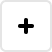
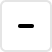
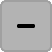
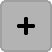
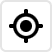
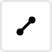
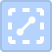
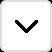
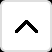
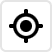
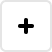
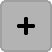
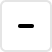
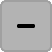
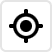
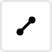
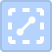
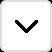
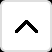
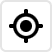

In [26]:
import numpy as np
from lets_plot import *
LetsPlot.setup_html()
np.random.seed(42)
n = 20
data = {
    'v': 1 + np.random.randint(5, size=n)
}
ggplot(data) + \
    geom_bar(aes(fill=as_discrete('v')), size=0, show_legend=False) + \
    scale_x_continuous(expand=[0, 0]) + \
    scale_y_continuous(expand=[0, 0]) + \
    coord_polar(theta='y')

## 10. Axes and Grid

Axis lines, tick marks, and grid lines are drawn as ordinary line primitives, so the XKCD wobble naturally flows into them. The effect is subtle with default themes — bumping the grid and axis sizes makes the hand-drawn frame much more obvious.

In [20]:
# Bold axes and grid put the wobble on the chart frame itself
axis_data = pd.DataFrame({
    'x': list(range(1, 11)),
    'y': [2, 4, 3, 8, 6, 9, 7, 11, 10, 13]
})

(
    ggplot(axis_data, aes('x', 'y'))
    + geom_point(size=5, color='#D32F2F')
    + scale_x_continuous(breaks=list(range(1, 11)))
    + scale_y_continuous(breaks=list(range(0, 15, 2)))
    + ggtitle('XKCD style on axes and grid')
    + theme(
        panel_grid_major=element_line(color='#666666', size=1),
        panel_grid_minor=element_line(color='#999999', size=0.5),
        axis_line=element_line(color='black', size=2),
        axis_ticks=element_line(color='black', size=1.5),
        axis_ticks_length=8,
    )
)

In [21]:
# Side-by-side: default frame vs. an emphasized one
compare_data = pd.DataFrame({
    'x': np.linspace(0, 10, 40),
    'y': np.sin(np.linspace(0, 10, 40)) * 5 + 5
})

base = (
    ggplot(compare_data, aes('x', 'y'))
    + geom_line(size=1.5, color='#1976D2')
    + geom_point(size=3, color='#1976D2')
)

loud = theme(
    panel_grid_major=element_line(color='#555555', size=1.2),
    panel_grid_minor=element_line(color='#AAAAAA', size=0.6),
    axis_line=element_line(color='black', size=2),
    axis_ticks=element_line(color='black', size=1.5),
    axis_ticks_length=8,
)

gggrid([
    base + theme_classic() + ggtitle('theme_classic() — minimal frame'),
    base + theme_bw() + loud + ggtitle('Emphasized axes & grid'),
], ncol=2)

## Implementation Notes

The XKCD wobble effect is applied by:

1. **Subdividing** line segments into smaller chunks (~10 pixels)
2. **Adding perpendicular displacement** with random amplitude (~2 pixels)
3. **Using a fixed seed** (42) for reproducible results

Affected geoms:
- Lines: `geom_line`, `geom_path`, `geom_segment`, `geom_curve`
- Areas: `geom_area`, `geom_ribbon`, `geom_density`
- Rectangles: `geom_bar`, `geom_tile`, `geom_rect`, `geom_histogram`
- Other: `geom_polygon`, `geom_pie`, `geom_errorbar`, `geom_lollipop`

The effect is applied **after** the coordinate transform (in pixel space), so it works uniformly across Cartesian and polar coordinates, and it also shows up on the chart frame — axis lines, tick marks, and grid lines.